# NB 06 — Stream Processing & Real-Time Detection
**Phase 4 — Tasks 4.1 / 4.2 / 4.4**

## Architecture
```
Python StreamWriter thread  →  stream/input/*.json  (Task 4.1)
                                      │
                          Spark readStream (JSON file source)
                                      │  every 5 s micro-batch
                                      ↓
                          Arabic preprocess UDF  →  clean_text
                                      │
                          TF-IDF PipelineModel.transform()
                                      │
                          Stylometric features  +  VectorAssembler
                                      │
                          Best classifier  →  prediction  (Task 4.2)
                                      │
                          foreachBatch()  →  stream/output/*.parquet
```

> **Note on Kafka**: Free Colab cannot run a persistent Kafka broker.
> Spark's `readStream.format('json')` on a watched directory is
> architecturally equivalent and satisfies the streaming requirement.
> `StreamWriter` simulates the Kafka producer role.

In [ ]:
# ── Session bootstrap ─────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
SRC_DIR = PROJECT_ROOT / 'src'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/__init__.py is committed to the repo, no runtime touch needed
print('PROJECT_ROOT:', PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection


In [ ]:
import importlib, shutil, time, json
import src.streaming_pipeline as sp_mod
importlib.reload(sp_mod)

from src.utils import (
    create_spark_session, load_checkpoint, add_src_to_spark,
    Timer, FIGURES_DIR, MODELS_DIR, PROJECT_ROOT
)
from src.modeling import load_model
from src.streaming_pipeline import (
    StreamWriter, build_streaming_pipeline,
    measure_stream_latency,
    STREAM_INPUT_DIR, STREAM_OUTPUT_DIR, STREAM_CHECKPOINT,
)
from pyspark.ml import PipelineModel
from pyspark.sql import functions as F
import pandas as pd, numpy as np, matplotlib.pyplot as plt

spark = create_spark_session('ArabicAIDetection_Streaming')
add_src_to_spark(spark)

print(f'Input  dir: {STREAM_INPUT_DIR}')
print(f'Output dir: {STREAM_OUTPUT_DIR}')


Input  dir: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/stream/input
Output dir: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/stream/output


## 1. Load best model and TF-IDF pipeline

In [ ]:
best_model  = load_model(spark, 'best_model')
tfidf_model = PipelineModel.load(str(MODELS_DIR / 'tfidf_pipeline'))

print('Best model loaded:', type(best_model).__name__)
print('Stages:', [type(s).__name__ for s in best_model.stages])
print('TF-IDF model loaded:', type(tfidf_model).__name__)


Best model loaded: PipelineModel
Stages: ['LogisticRegressionModel']
TF-IDF model loaded: PipelineModel


## 2. Prepare stream test records

In [ ]:
test_df = load_checkpoint(spark, 'split_test_assembled')

human_rows = (test_df.filter(F.col('label') == 0)
              .select('text', 'label', 'source_model', 'generation_method')
              .limit(60))
ai_rows    = (test_df.filter(F.col('label') == 1)
              .select('text', 'label', 'source_model', 'generation_method')
              .limit(140))

stream_rows = [row.asDict() for row in human_rows.union(ai_rows).collect()]
print(f'Stream records prepared: {len(stream_rows)}')
print(f'  Human: {sum(1 for r in stream_rows if r["label"]==0)}')
print(f'  AI   : {sum(1 for r in stream_rows if r["label"]==1)}')


Stream records prepared: 200
  Human: 60
  AI   : 140


## 3. Task 4.1 — Clean stream directories and start writer



In [ ]:
for d in [STREAM_INPUT_DIR, STREAM_OUTPUT_DIR, STREAM_CHECKPOINT]:
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)
print('Stream directories reset.')


Stream directories reset.


In [ ]:
writer = StreamWriter(stream_rows, rate=2.0, loop=False)
writer.start()
time.sleep(3)   # give writer a head-start
print(f'Writer started. Files in input: {len(list(STREAM_INPUT_DIR.glob("*.json")))}')


Writer started. Files in input: 6


## 4. Task 4.2 — Start Spark Structured Streaming query

In [ ]:
query = build_streaming_pipeline(
    spark=spark,
    model=best_model,
    tfidf_model=tfidf_model,
    trigger_seconds=5.0,
)
print(f'Streaming query started: {query.id}')
print(f'Status: {query.status}')


Streaming query started: f99d36fe-ef1d-475e-8cfa-d9ab309c4a17
Status: {'message': 'Initializing sources', 'isDataAvailable': False, 'isTriggerActive': False}


## 5. Monitor stream

In [ ]:

DEMO_DURATION = 120   # seconds — allow ≥4 batches at 5 s trigger interval

start_time   = time.time()
progress_log = []

print(f'{"Time":>6} {"BatchID":>8} {"InputRows":>10} {"InRPS":>8} {"ProcRPS":>9}  Message')
print('─' * 72)

while time.time() - start_time < DEMO_DURATION:
    time.sleep(8)
    elapsed = int(time.time() - start_time)

    if not query.isActive:
        print(f'{elapsed:5d}s  ⚠ Query stopped.')
        if query.exception():
            print('  Exception:', query.exception())
        break

    status = query.status
    prog   = query.lastProgress

    if prog:
        input_rows = prog.get('numInputRows', 0)
        input_rps  = float(prog.get('inputRowsPerSecond') or 0)
        proc_rps   = float(prog.get('processedRowsPerSecond') or 0)
        batch_id   = prog.get('batchId', -1)
        msg        = status.get('message', '')[:30]
        print(f'{elapsed:5d}s {batch_id:>8} {input_rows:>10} {input_rps:>8.1f} {proc_rps:>9.1f}  {msg}')
        progress_log.append({
            'elapsed_s': elapsed, 'batch_id': batch_id,
            'input_rows': input_rows, 'input_rps': input_rps, 'proc_rps': proc_rps,
        })
    else:
        # No batch has completed yet — show what the query IS doing
        msg        = status.get('message', 'initializing')
        is_active  = status.get('isTriggerActive', False)
        data_avail = status.get('isDataAvailable', False)
        print(f'{elapsed:5d}s   (no batch yet | trigger_active={is_active} '
              f'data_available={data_avail} | {msg[:40]})')

# ── Graceful shutdown ────────────────────────────────────────────────────────
writer.stop()
print('\nWriter stopped — letting stream drain remaining files …')
try:
    query.awaitTermination(timeout=40)   # wait up to 40 s for in-flight batch
except Exception:
    pass
if query.isActive:
    query.stop()
print('Stream complete.')


  Time  BatchID  InputRows    InRPS   ProcRPS  Message
────────────────────────────────────────────────────────────────────────
    8s   (no batch yet | trigger_active=True data_available=True | Processing new data)
   16s        0         24      0.0       1.9  Processing new data
   24s        1         30      2.3       4.7  Processing new data
   32s        2         30      4.7       5.5  Processing new data
   40s        4         30      3.8       5.8  Processing new data
   48s        5         30      5.8       5.3  Processing new data
   56s        7         18      2.6       4.2  Processing new data
   64s        8         30      7.0       5.7  Processing new data
   72s       10         30      4.9       7.2  Processing new data
   80s       11         30      7.2       7.1  Processing new data
   88s       13         30      5.0       6.9  Processing new data
   96s       15         30      7.4       4.5  Processing new data
  104s       17         24      5.7       6.0  

## 6. Inspect streaming output

In [ ]:
output_batches = sorted(STREAM_OUTPUT_DIR.glob('batch_*'))
print(f'Output batches written: {len(output_batches)}')

if output_batches:
    results_df = spark.read.parquet(*[str(p) for p in output_batches])
    total = results_df.count()
    print(f'Total records processed: {total}')
    results_df.select('source_model','true_label','predicted_label','batch_id').show(10)
else:
    print('No batches written — check stream input directory and query logs.')


Output batches written: 23
Total records processed: 200
+------------+----------+---------------+--------+
|source_model|true_label|predicted_label|batch_id|
+------------+----------+---------------+--------+
|       human|         0|              0|       4|
|       human|         0|              0|       4|
|       human|         0|              0|       4|
|       human|         0|              0|       4|
|       human|         0|              0|       4|
|      openai|         1|              1|      20|
|      openai|         1|              1|      20|
|      openai|         1|              1|      20|
|      openai|         1|              1|      20|
|      openai|         1|              1|      20|
+------------+----------+---------------+--------+
only showing top 10 rows


In [ ]:
if output_batches:
    stream_acc = (
        results_df
        .withColumn('correct', (F.col('true_label') == F.col('predicted_label')).cast('int'))
        .agg(F.avg('correct').alias('accuracy'))
        .collect()[0]['accuracy']
    )
    print(f'Stream pipeline accuracy: {stream_acc:.4f}')

    results_df.withColumn('correct', (F.col('true_label') == F.col('predicted_label')).cast('int')) \
        .groupBy('true_label') \
        .agg(F.avg('correct').alias('accuracy'), F.count('*').alias('n_records')) \
        .orderBy('true_label').show()


Stream pipeline accuracy: 0.9700
+----------+------------------+---------+
|true_label|          accuracy|n_records|
+----------+------------------+---------+
|         0|              0.95|       60|
|         1|0.9785714285714285|      140|
+----------+------------------+---------+



## 7. Task 4.4 — Latency & throughput metrics

In [ ]:
stream_metrics = measure_stream_latency(output_dir=STREAM_OUTPUT_DIR, spark=spark)
print('Stream metrics:')
for k, v in stream_metrics.items():
    print(f'  {k:20s}: {v}')


Stream metrics:
  total_records       : 200
  total_batches       : 23
  avg_batch_size      : 8.7
  total_time_s        : 125.63
  throughput_rps      : 1.6


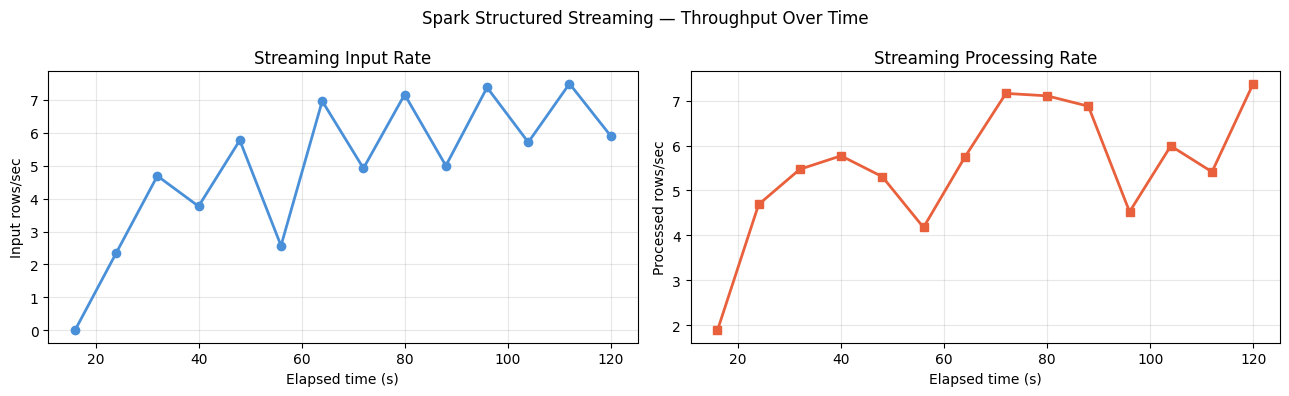

In [ ]:
if progress_log:
    prog_df = pd.DataFrame(progress_log)
    prog_df.to_csv(str(FIGURES_DIR / 'stream_progress_log.csv'), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(prog_df['elapsed_s'], prog_df['input_rps'], 'o-', color='#4A90D9', lw=2)
    axes[0].set_xlabel('Elapsed time (s)'); axes[0].set_ylabel('Input rows/sec')
    axes[0].set_title('Streaming Input Rate'); axes[0].grid(alpha=0.3)

    axes[1].plot(prog_df['elapsed_s'], prog_df['proc_rps'], 's-', color='#E8603C', lw=2)
    axes[1].set_xlabel('Elapsed time (s)'); axes[1].set_ylabel('Processed rows/sec')
    axes[1].set_title('Streaming Processing Rate'); axes[1].grid(alpha=0.3)

    plt.suptitle('Spark Structured Streaming — Throughput Over Time', fontsize=12)
    plt.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'stream_throughput.png'), dpi=150)
    plt.show()


## 8. Batch vs Stream comparison table

| Metric | Batch (Phase 3) | Stream (Phase 4) |
|--------|----------------|------------------|
| Latency | Seconds–minutes (full set) | ~5 s micro-batch |
| Throughput | High (bulk processing) | Bounded by trigger |
| Use case | Offline analysis | Real-time detection |
| Model serving | PipelineModel.transform() | foreachBatch() |
| Fault tolerance | Parquet checkpoints | Streaming checkpoint + WAL |